In [3]:
import pandas as pd

In [4]:
df = pd.read_csv("House Price Prediction Dataset.csv")

In [5]:
df.shape

(2000, 10)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


In [7]:
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [8]:
df = df.drop(columns=['Id'])

In [9]:
df.isnull().sum()

Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

In [10]:
# Checking unique categories in object columns before encoding
# to decide whether to use get_dummies or label encoding

df['Location'].value_counts()

Location
Downtown    558
Urban       485
Suburban    483
Rural       474
Name: count, dtype: int64

In [9]:
df['Garage'].value_counts()

Garage
No     1038
Yes     962
Name: count, dtype: int64

In [10]:
df['Condition'].value_counts()

Condition
Fair         521
Excellent    511
Poor         507
Good         461
Name: count, dtype: int64

In [11]:
#decoding object data into int for model traing
df = pd.get_dummies(df, columns=['Location', 'Condition'], dtype=int)

In [12]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Garage'] = le.fit_transform(df['Garage'])

In [13]:
df.head()

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Garage,Price,Location_Downtown,Location_Rural,Location_Suburban,Location_Urban,Condition_Excellent,Condition_Fair,Condition_Good,Condition_Poor
0,1360,5,4,3,1970,0,149919,1,0,0,0,1,0,0,0
1,4272,5,4,3,1958,0,424998,1,0,0,0,1,0,0,0
2,3592,2,2,3,1938,0,266746,1,0,0,0,0,0,1,0
3,966,4,2,2,1902,1,244020,0,0,1,0,0,1,0,0
4,4926,1,4,2,1975,1,636056,1,0,0,0,0,1,0,0


In [13]:
#Model Training
from sklearn.model_selection import train_test_split

X = df.drop(['Price'],axis=1)
Y = df['Price']


In [14]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [18]:
from sklearn.ensemble  import GradientBoostingRegressor
gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train,Y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [19]:
pred1 = gbr.predict(X_test)
print(pred1)

[713245.53555666 481201.13864943 506527.28013693 553714.82480691
 537631.0085801  539068.78140166 504734.23544794 562570.43431558
 539147.62693589 560429.69924674 540119.6574948  581782.78050712
 551622.08180849 540750.13618303 535405.12889431 514669.98729642
 562596.52577836 598567.0370981  581647.18110262 467764.01216727
 553615.52256059 426040.65735719 529656.37599363 631742.57165801
 533658.86947896 653443.05438818 423229.90564553 543940.80397909
 539496.342654   510686.48678547 410304.38885529 531952.02137811
 607105.2786746  553809.53431859 388189.68739279 532753.22081097
 564745.86285024 486458.81132352 594283.20376157 484771.56027436
 541789.97682311 535861.21176016 570441.63580661 517731.59605055
 517339.11589573 551421.66708774 540102.02390213 519727.8400955
 577639.12875664 454449.50011372 595038.80732447 544091.72563789
 603966.90195181 522670.5474818  610847.85603888 551786.62821948
 566168.17286768 424955.95457413 555136.68075789 509276.0947453
 528034.55485088 536126.968

In [20]:
#MAE and RMSE
from sklearn.metrics import mean_absolute_error,mean_squared_error
import numpy as np

mae = mean_absolute_error(Y_test,pred1)
rmse = np.sqrt(mean_squared_error(Y_test,pred1))

print(f"MAE: {mae}")
print(f"RMSE: {rmse}")

MAE: 247238.21766451627
RMSE: 285822.24424551416


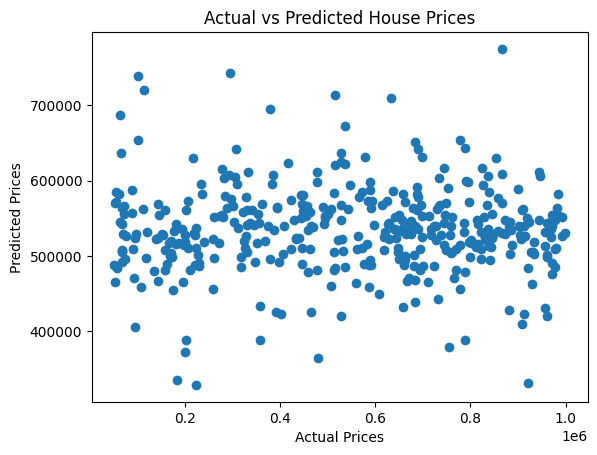

In [22]:
#visualzing actual vs predicted prices
import matplotlib.pyplot as plt
plt.scatter(Y_test, pred1)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted House Prices')
plt.show()
